In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle

In [16]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [167]:

odir = "../ps_data"
with open(f"{odir}/halo_exclusion/R1=0.3_R2=0.6.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal2 = pickle.load(f)
print("shotnoise", Pk_gal2.attrs["shotnoise"])

shotnoise 10.41408534469941


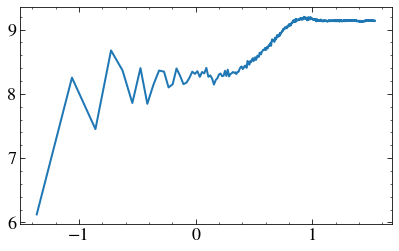

In [124]:
plt.plot(np.log10(Pk_gal2["k"]), Pk_gal2["power"].real)

(-0.5, 0.2)

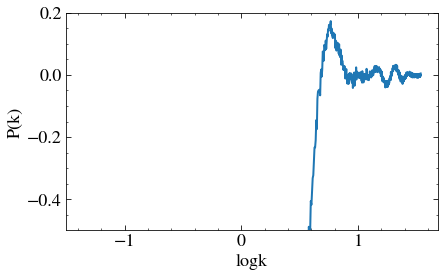

In [22]:
plt.plot(np.log10(Pk_gal2["k"]), Pk_gal2["power"].real-(Pk_gal2.attrs["shotnoise"]))
plt.ylabel("P(k)")
plt.xlabel("logk")
plt.ylim(-0.5,0.2)


shotnoise:  9.139232570203458


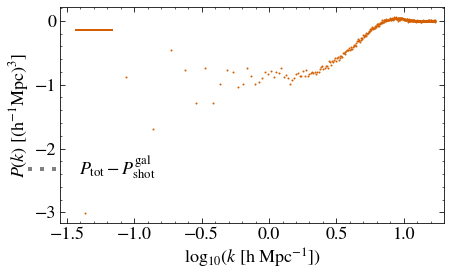

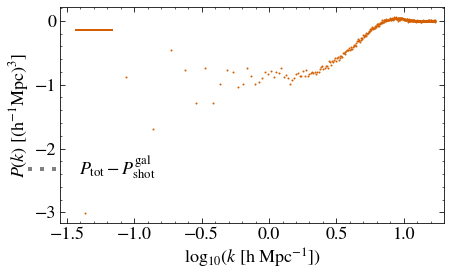

In [125]:
ps.compare_ps_plot([Pk_gal2], shotnoise_subtracted_ps=True,log=False, var=False, shotnoise_ps=False, total_ps=False)
#plt.ylim(-0.2,0.2)

shotnoise:  10.41408534469941


(-0.2, 0.2)

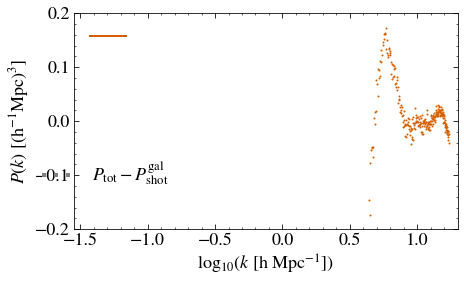

In [28]:
ps.compare_ps_plot([Pk_gal2], shotnoise_subtracted_ps=True,log=False, var=False, shotnoise_ps=False, total_ps=False)
plt.ylim(-0.2,0.2)


shotnoise:  9.139232570203458


(-3.0, 3.0)

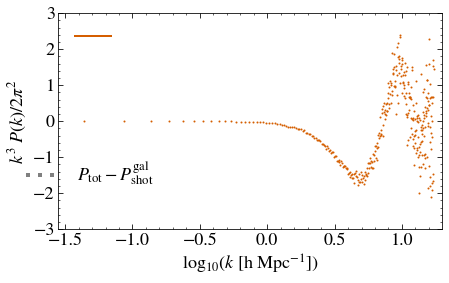

In [126]:
ps.compare_ps_plot([Pk_gal2], shotnoise_subtracted_ps=True,log=False, var=True, shotnoise_ps=False, total_ps=False)
plt.ylim(-3,3)


In [77]:
def result_k1(k, R):
    result2 = 4 * np.pi * (2*R*k*np.cos(2*k*R) - np.sin(2*k*R))/ k**3
    return result2

In [78]:
def W_R(k, R=1):
    R = 2*R
    return 3 * (np.sin(k*R) - k*R*np.cos(k*R))/(k*R)**3

In [79]:
def V_excl(R=1):
    R = 2*R
    return (4*np.pi*R**3)/3

In [83]:
def result_k(k, R):
    result2 = -V_excl(R)*W_R(k,R)
    return result2

In [171]:
p1 = 0.5
p2 = 0.5
# Ntot =  827257
# p1 = 418429/Ntot
# p2 = 408828/Ntot
# print(p1)
# print(p2)

R1 = 0.3
R2 = 0.6
tot_result = (p1**2 + 2*p1*p2 - 1)*result_k(k,R2) - (2*p1*p2)*result_k(k,(R1+R2)/2) - (p1**2)*result_k(k,R1)

shotnoise:  10.41408534469941


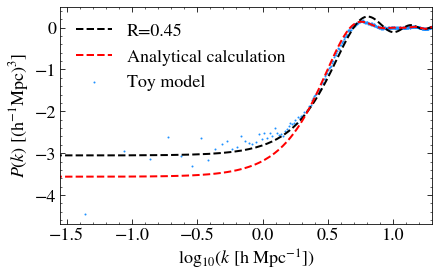

In [175]:

fig,ax = plt.subplots()
k =np.concatenate(([10**-2],Pk_gal2["k"]))
coef = k**3/(2*np.pi**2)
#ax.plot(np.log10(k), coef*result_k(k,0.3), linestyle="dashed", color="k", label="R=0.3")
#ax.plot(np.log10(k), coef*result_k(k,0.3), linestyle="dashed", c="red", label="R=0.3")
ax.plot(np.log10(k), result_k(k,0.45), linestyle="dashed", c="black", label="R=0.45")
ax.plot(np.log10(k), -tot_result, linestyle="dashed", c="red", label="Analytical calculation")


ps.compare_ps_plot([Pk_gal2], labels=["Toy model"], len_k=689, shotnoise_subtracted_ps=True, total_ps=False, shotnoise_ps=False, log=False,var=False, create_fig=False, ax=ax, grey_legend=False, color_legend=False, color_list=["DodgerBlue"], bbox_to_anchor_color=(0,1))
solid_line = Line2D([],[],color="k", linestyle="dashed", label="Analytical (R=0.6)")

#leg = ax.legend(handles=[solid_line], bbox_to_anchor=(0,0.3), loc="lower left")
#ax.add_artist(leg)
plt.legend()
#ax.set_xlim(-0.5, 1.55)

#plt.savefig("../figures/exclusion_ps_coef.pdf", format="pdf", bbox_inches="tight")

shotnoise:  10.41408534469941


(-1.55, 1.55)

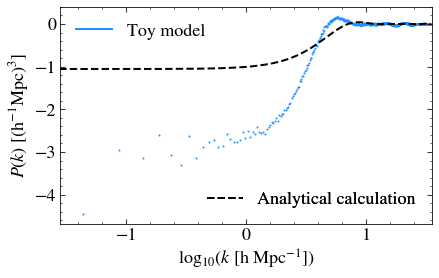

In [170]:

fig,ax = plt.subplots()
k =np.concatenate(([10**-2],Pk_gal2["k"]))
#ax.plot(np.log10(k), result_k(k,0.45), linestyle="dashed", color="k")
ax.plot(np.log10(k), -tot_result, linestyle="dashed", color="k")

ps.compare_ps_plot([Pk_gal2], labels=["Toy model"], len_k=689, shotnoise_subtracted_ps=True, total_ps=False, shotnoise_ps=False, log=False,var=False, create_fig=False, ax=ax, grey_legend=False, color_list=["DodgerBlue"])
solid_line = Line2D([],[],color="k", linestyle="dashed", label="Analytical calculation")

leg = ax.legend(handles=[solid_line], bbox_to_anchor=(1,0), loc="lower right")
ax.add_artist(leg)

ax.set_xlim(-1.55, 1.55)
#plt.ylim(-0.2,0.5)
#plt.savefig("../figures/exclusion_ps.pdf", format="pdf", bbox_inches="tight")

shotnoise:  9.139232570203458


(-1.55, 1.55)

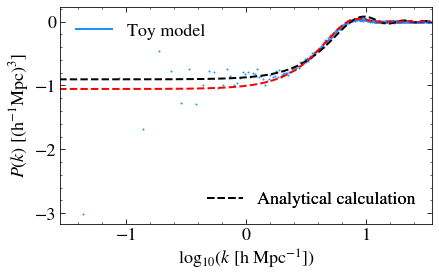

In [164]:

fig,ax = plt.subplots()
k =np.concatenate(([10**-2],Pk_gal2["k"]))
ax.plot(np.log10(k), result_k(k,0.3), linestyle="dashed", color="k")
ax.plot(np.log10(k), -tot_result, linestyle="dashed", color="red", label="R=0.3")

ps.compare_ps_plot([Pk_gal2], labels=["Toy model"], len_k=689, shotnoise_subtracted_ps=True, total_ps=False, shotnoise_ps=False, log=False,var=False, create_fig=False, ax=ax, grey_legend=False, color_list=["DodgerBlue"])
solid_line = Line2D([],[],color="k", linestyle="dashed", label="Analytical calculation")

leg = ax.legend(handles=[solid_line], bbox_to_anchor=(1,0), loc="lower right")
ax.add_artist(leg)

ax.set_xlim(-1.55, 1.55)
#plt.ylim(-0.2,0.5)
#plt.savefig("../figures/exclusion_ps.pdf", format="pdf", bbox_inches="tight")

shotnoise:  10.41408534469941


(-0.5, 1.55)

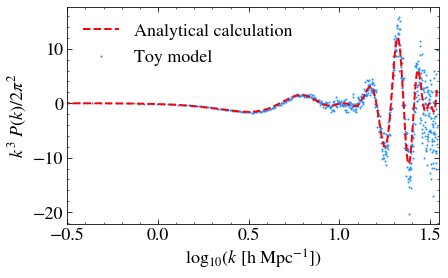

In [176]:

fig,ax = plt.subplots()
k =np.concatenate(([10**-2],Pk_gal2["k"]))
coef = k**3/(2*np.pi**2)
#ax.plot(np.log10(k), coef*result_k(k,0.3), linestyle="dashed", color="k", label="R=0.3")
#ax.plot(np.log10(k), coef*result_k(k,0.3), linestyle="dashed", c="red", label="R=0.3")
#ax.plot(np.log10(k), coef*result_k(k,0.3), linestyle="dashed", c="black", label="R=0.3")
ax.plot(np.log10(k), -coef*tot_result, linestyle="dashed", c="red", label="Analytical calculation")


ps.compare_ps_plot([Pk_gal2], labels=["Toy model"], len_k=689, shotnoise_subtracted_ps=True, total_ps=False, shotnoise_ps=False, log=False,var=True, create_fig=False, ax=ax, grey_legend=False, color_legend=False, color_list=["DodgerBlue"], bbox_to_anchor_color=(0,1))
solid_line = Line2D([],[],color="k", linestyle="dashed", label="Analytical (R=0.6)")

#leg = ax.legend(handles=[solid_line], bbox_to_anchor=(0,0.3), loc="lower left")
#ax.add_artist(leg)
plt.legend()
ax.set_xlim(-0.5, 1.55)

#plt.savefig("../figures/exclusion_ps_coef.pdf", format="pdf", bbox_inches="tight")